# **Analysis of Populist Groups**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Import dataset
ep = pd.read_csv('../data/ep_speeches_classified_total.csv')

In [15]:
ep['party'].unique()

array(['Greens/EFA', 'PPE', 'S&D', 'Renew', 'ID', 'The Left', 'ECR', 'NI',
       '-', 'EFDD', 'UEN', 'IND/DEM'], dtype=object)

In [12]:
ep['party'] = ep['party'].replace({
    'GUE/NGL': 'The Left',
    'ALDE': 'Renew',
    'ENF': 'ID',
})

In [8]:
# Import dataset on populist ep party groups 
populist_groups = pd.read_excel('../data/ep_populist_party_data.xlsx')
populist_groups.head()

,country,year,party,party_name_short,party_eng,party_year,ep_political_group,vote_share,seats,rightwing,radicalright,leftwing,valence,party_entry,group_change
0,Austria,1999,Freiheitliche Partei Österreichs,FPÖ,Freedom Party of Austria,FPÖ_1999,NI,23.4,5,1,1,0,0,1,0
1,Austria,2004,Freiheitliche Partei Österreichs,FPÖ,Freedom Party of Austria,FPÖ_2004,NI,6.3,1,1,1,0,0,0,0
2,Austria,2009,Freiheitliche Partei Österreichs,FPÖ,Freedom Party of Austria,FPÖ_2009,NI,12.7,2,1,1,0,0,0,0
3,Austria,2014,Freiheitliche Partei Österreichs,FPÖ,Freedom Party of Austria,FPÖ_2014,ENF,19.7,4,1,1,0,0,0,1
4,Austria,2019,Freiheitliche Partei Österreichs,FPÖ,Freedom Party of Austria,FPÖ_2019,ID,17.2,3,1,1,0,0,0,1


In [13]:
populist_groups['ep_political_group'].unique()

array(['NI', 'ENF', 'ID', 'ECR', 'EPP', 'ALDE', 'Renew', 'UEN', 'EFD',
       'The Left', 'GUE/NGL', 'EDD', 'IND/DEM', 'EFDD', 'PSE'],
      dtype=object)

In [16]:
populist_groups['ep_political_group'] = populist_groups['ep_political_group'].replace({
    'EPP': 'PPE',
    'PSE': 'S&D',
    'GUE/NGL': 'The Left',
    'ALDE': 'Renew',
    'EDD': 'IND/DEM',
    'EFD': 'EFDD',
    'ENF': 'ID',
})

### Metrics on Populist Parties in EP

In [17]:
# Populist parties per legislative period
populist_groups['year'].value_counts().sort_index()

year
1999    10
2004    18
2009    25
2014    25
2019    32
Name: count, dtype: int64

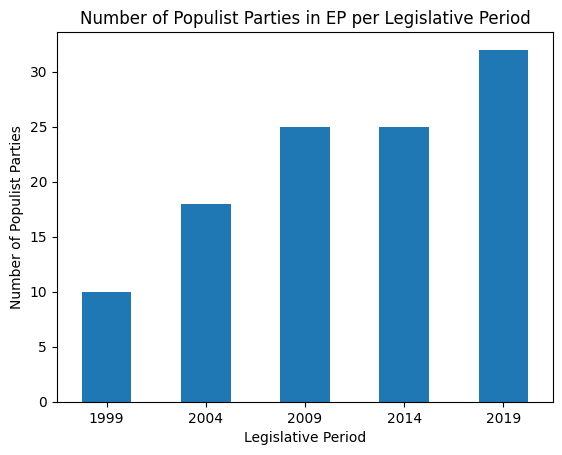

In [18]:
populist_groups['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Populist Parties in EP per Legislative Period')
plt.xlabel('Legislative Period')
plt.ylabel('Number of Populist Parties')
plt.xticks(rotation=0)
plt.show()



In [19]:
# Populist parties per EP party group 
populist_groups['ep_political_group'].value_counts()

ep_political_group
NI          24
ECR         19
The Left    16
PPE         15
ID          10
EFDD        10
UEN          6
Renew        5
IND/DEM      4
S&D          1
Name: count, dtype: int64

In [26]:
members_per_year = populist_groups.groupby(['year', 'ep_political_group'])['party'].nunique().reset_index(name='members')
print(members_per_year)

    year ep_political_group  members
0   1999            IND/DEM        1
1   1999                 NI        4
2   1999                PPE        1
3   1999           The Left        3
4   1999                UEN        1
5   2004            IND/DEM        3
6   2004                 NI        4
7   2004                PPE        2
8   2004              Renew        1
9   2004                S&D        1
10  2004           The Left        2
11  2004                UEN        5
12  2009                ECR        3
13  2009               EFDD        7
14  2009                 NI        9
15  2009                PPE        3
16  2009              Renew        1
17  2009           The Left        2
18  2014                ECR        7
19  2014               EFDD        3
20  2014                 ID        4
21  2014                 NI        2
22  2014                PPE        4
23  2014              Renew        1
24  2014           The Left        4
25  2019                ECR        9
2

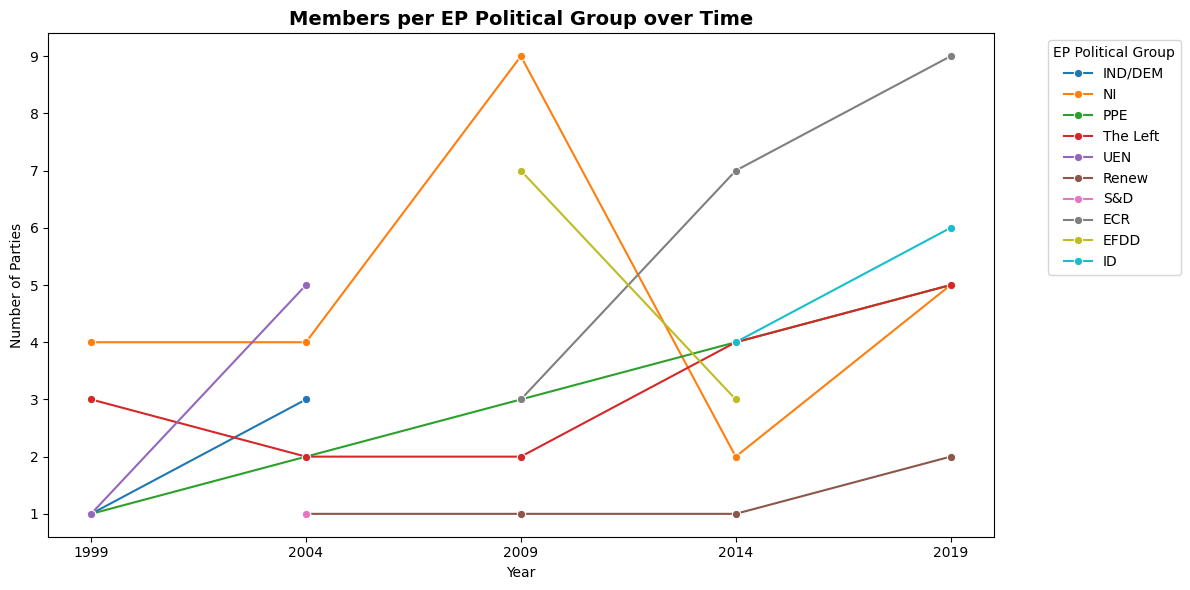

In [28]:
# Calculate
# Visualise
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=members_per_year,
    x='year',
    y='members',
    hue='ep_political_group',
    marker='o',
)
plt.xticks(ticks=members_per_year['year'].unique())
plt.title('Members per EP Political Group over Time', fontsize=14, fontweight='bold')
plt.ylabel('Number of Parties')
plt.xlabel('Year')
plt.legend(title='EP Political Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('../outputs/graphs/members_per_group_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
members_per_year = populist_groups.groupby('year')['ep_political_group'].value_counts.sum()

AttributeError: 'function' object has no attribute 'sum'

In [ ]:
# Members per group over the years
members_per_year = populist_groups.groupby('year')['ep_political_group'].value_counts.sum()
members_per_group = populist_groups.groupby(['year', 'ep_political_group'])['party'].sum().unstack().fillna(0)
members_per_group.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Number of Populist MEPs per EP Party Group and Legislative Period')
plt.xlabel('Legislative Period')
plt.ylabel('Number of Populist MEPs')
plt.xticks(rotation=0)
plt.legend(title='EP Party Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

TypeError: no numeric data to plot